In [1]:
#Librerías requeridas
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats as st

# Introducción

En este curso se trata el análisis exploratorios de datos (EDA por sus siglas en Inglés *Exploratory Data Analysis*). En términos simples podríamos decir que es la exploración visual de los datos, esto con le objectivo de obtener información que permita identificar relaciones o patrones en los datos que nos permintan orientar mejor el análisis de los mismos. 

Por ejemplo, ¿Qué pasa si se está tratando con datos de precios y encuentras un número negativo? Lo anterior es probable que se trate de un error. Esto tipo de situaciones son muy fácil de determinar visualmente si utilizamos las herramientas de visualización adecuadas. Además de encontrar datos erroneos podemos identificar patrones, tendencias, relaciones o sumarizar nuestros datos. Una de las formas más simples es mediante las medidas de tendendia central.  

## Medidas de tendencia Central

Comencemos con un caso simple, donde solo tenemos un vector unidimensional de datos. Este lo podemos generar utilizando la librería numpy.

In [2]:
np.random.seed(1) # Para reproducir los mismos valores entre ejecución (semilla constante)
data1Da=np.random.normal(11,size=200) #Generamos 200 valores tomados de una distribución gaussiana com media 10
data1Db=np.random.normal(14,size=100) #Generamos 100 valores tomados de una distribución gaussiana com media 15

(array([ 1.,  1., 10., 13., 21., 19., 18.,  6.,  6.,  5.]),
 array([11.206915  , 11.73116036, 12.25540573, 12.77965109, 13.30389646,
        13.82814182, 14.35238719, 14.87663255, 15.40087792, 15.92512328,
        16.44936865]),
 <BarContainer object of 10 artists>)

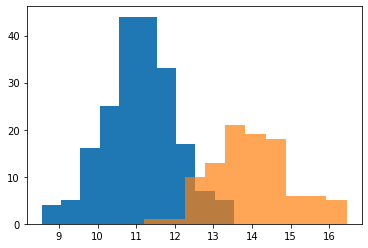

In [3]:
plt.hist(data1Da) # Grafiacamos el histograma 
plt.hist(data1Db, alpha=0.7)# Grafiacamos el histograma y modificamos el canal alfa.

Una de las medidas básicas sin la medidades de centralidad, las cuales nos permiten identicficar el *centro* de los datos bajo estudio. En este curso es de intéres identificarlo visualmente. 

### Media

Dado un conjuto de datos $N$ puntos $x_i$ (podría ser vectores), la media $\mu$ se define como:

$$ \mu=\frac{1}{N} \sum_{i=1}^N x_i $$

La librería numpy ya cuenta con una implementación y se puede utilizar mediante **mean**. En algunos caso se podría desear que cada uno de los elmetos tuviese diferente peso, en ese caso utilizariamos **average**. 

In [4]:
np.mean(data1Da) 

11.10668881484795

### Mediana
Está se obtiene ordenando todos los datos y tomando el elemento que se ubique en la mitad. Por ejemplo $[0,4,7,9,10]$ la mediana sería $7$. En caso de que el numero de elemento fuera par, se promedian los dos elementos de la mitad. Podríamos calcular la mediana mediane el siguiente método:

In [5]:
def mediana(data):
    N=len(data)
    sdata=sorted(data)
    if N%2:
        return sdata[N//2]
    return (sdata[N//2-1]+sdata[N//2])/2
        

In [6]:
print(mediana([0,4,7,9,10]))## N es impar

7


In [7]:
print(mediana([0,4,7,9])) ## N es par

5.5


La función numpy implementa la mediana en el método **median**

In [8]:
print(np.median([0,4,7,9])) # N par
print(np.median([0,4,7,9,10])) # N impar

5.5
7.0


Note que la mediana muchas veces resultat más útil que la media, esto dado a que es más robusta a datos atípicos. Si embargo, en dimensiones altas la mediana es más costosa de computar y su intepretabilidad es más limitada.

Considere el siguiente ejemplo donde incluimos un dato atípico:

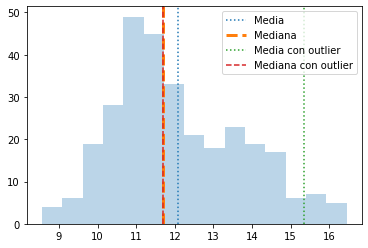

In [9]:
data1D=np.concatenate((data1Da,data1Db)) # concatenamos los dados del primer ejemplo
plt.hist(data1D, alpha=0.3, bins=15)
data1Doutlier=np.concatenate((data1D,[1000])) # Generamos dato donde agregamos un dato atípico
plt.axvline(np.mean(data1D), ls=":", label="Media",c='C0')  # Agregamos una linea en la posición de los datos
plt.axvline(np.median(data1D), ls="--", label="Mediana",c='C1',linewidth=3)
plt.axvline(np.mean(data1Doutlier), ls=":", label="Media con outlier",c='C2')
plt.axvline(np.median(data1Doutlier), ls="--", label="Mediana con outlier",c='C3')
plt.legend()

Como se puede observar en la figura anterior, mientras que la mediana se mantiene practicamente igual, la media se movio de 12 a 15.

### Moda

Otra medida robusta a valores atípicos, el la moda la cual obtiene el valor más común (solo se aplica directamente a datos discretos). Si se tiene valores continuos, primero se deben agrupar los datos (por ejemplo en rangos).  Numpy no implementa el la función moda, pero en la librerías de scipy.stats se tiene la función **mode**, pero podríamos codificarla como sigue:

In [10]:
def moda(data):
    vals, counts = np.unique(data, return_counts=True)
    max_count = np.argmax(counts)
    return vals[max_count]  

In [11]:
print(moda([0,7,2,5,7,7,8,3,2,1,7]))

7


In [12]:
print(st.mode([0,7,2,5,7,7,8,3,2,1,7]))# en este caso nos regresa la moda y su frecuencia  

ModeResult(mode=array([7]), count=array([4]))


La moda no resulta muy útil si se aplica la función mode a una distribución no continua:

In [13]:
st.mode(data1D)

ModeResult(mode=array([8.56516224]), count=array([1]))

Todos los valores son de frecuencia 1. Lo primero que debemos hacer es agrupar los datos (hacer un histograma de ellos) y después calcular la moda sobre el histograma. Sin embargo ahora tenermos el problema que se debe elegir el número de contenedores, los rangos, etc. Afortunadamente Numpy ya tiene un método para calcular histogramas.

In [14]:
hist, bordes = np.histogram(data1D, bins=5)

In [15]:
print(hist)
print(bordes)

[ 29 122  72  59  18]
[ 8.56516224 10.14200352 11.7188448  13.29568608 14.87252737 16.44936865]


Puede observase que el primero contenedor contiene 29 elementos y de un rango de 0 a 8.565, el segundo de 8.566 a 10.14 y contiene 122 elementos. El centro de cada contenedor podemos calcularlo como el punto medio de cada boder. La moda se puede como sigue:

In [16]:
centros =(bordes[1:] + bordes[:-1])/2 # Calculamos el centro de cada contenedor
moda = centros[hist.argmax()]
print(moda)

10.930424159843422


Repetimos lo anterior para 15 contenedores:

11.127529320172636


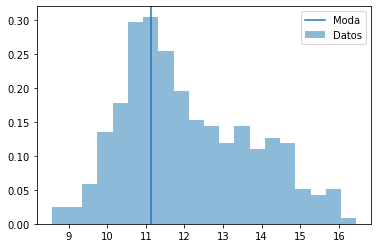

In [17]:
hist, bordes = np.histogram(data1D, bins=20)
centros =(bordes[1:] + bordes[:-1])/2 # Calculamos el centro de cada contenedor
moda = centros[hist.argmax()]
print(moda) # como podemos ver la moda cambio 
plt.hist(data1D, bins=20, density=True, label="Datos", alpha=0.5)
plt.axvline(moda, label="Moda")
plt.legend();

Comaparación entre las distintas medidas de centralidad

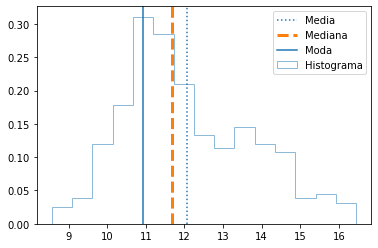

In [18]:
hist, bordes = np.histogram(data1D, bins=15)
centros =(bordes[1:] + bordes[:-1])/2 # Calculamos el centro de cada contenedor
moda = centros[hist.argmax()]# Calculamos la moda
plt.axvline(np.mean(data1D), ls=":", label="Media",c='C0')  # Agregamos una linea en la posición de la media
plt.axvline(np.median(data1D), ls="--", label="Mediana",c='C1',linewidth=3)# Agregamos una linea en la posición de la mediana
plt.hist(data1D, bins=15, density=True, label="Histograma", alpha=0.5, histtype="step")
plt.axvline(moda, label="Moda")# Agregamos una linea en la posición de la meoda
plt.legend();

## Medidas de dispersión y sus propiedades.

A continuación revisaremos como visualizar algunas medidas de dispersión de los datos.

### La Varianza
La varianza es una medida que indica que tan dispersos se encuentran los datos en torno a su media. En términos formales, es el valor esperado de la desviación al cuadrado de la media. Se calcula mediate la siguiente ecuación:

$$ Var = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2, $$

recuerde que $\mu$  la  definimos como la media de los datos. Podemos utilizar el método **var** en la libreía numpy.


In [19]:
np.var(data1D)

2.7616841881485734

### Desviación Estánda
Es la raíz cuadrada de la varianza. Se define como el valor absoluto esperado de la desviación de la media. Y podemos calcularla con el método  **std** en la libría numpy



In [20]:
print("Desviación Estándar",np.std(data1D))
print("Raíz cuadrada de la varianza",np.sqrt(np.var(data1D)))

Desviación Estándar 1.6618315763483895
Raíz cuadrada de la varianza 1.6618315763483895


###  Aproximación Gaussiana

Muchos datos pueden ser aproximados mediante una distribución gaussiana o normal. Una operación de visualización simples es utilizar la media y la desviación estándar empiricas para aproximar nuestro datos a un curva gaussiana. Para esto podemos utilizar la función *pdf*  del modulo norm en la librería scipy.stats. A continuación un ejemplo:

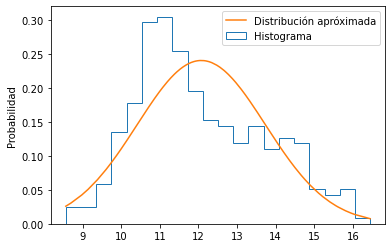

In [21]:
plt.hist(data1D, bins=20, density=True, histtype="step", label="Histograma")
media=np.mean(data1D) #Calculamos la media empírica de los datos
desviacion=np.std(data1D) #Calculamos la desviación estándar empírica de los datos
ys = st.norm.pdf(data1D, loc=media, scale=desviacion) # loc indica la media y scale la desviación
plt.plot(np.sort(data1D),ys[np.argsort(data1D)], label='Distribución apróximada') # Debermos ordenar los datos y alinear los valores estimados por la normal
plt.ylabel("Probabilidad")
plt.legend();

Aun cuando los datos de nuestro ejemplo nos son del todo simétricos, para este ejemplo en particular obtenemos una buena aproximación. Ahora vamos a cuantificar que tan asimétricos son los datos.

### Asimétria

Recodando que el primer *momento* está definido como el valor esperado, es decir la media, el segundo momento la varianza. El tercero sería la asimetría, usualmente representado por $\gamma_1$. 

$$\gamma_1 = \frac{\kappa_3}{\kappa_2^{3/2}} = \frac{E[(x-\mu)^3]}{E[(x-\mu)^2]^{3/2}}$$

Para estimar la asimétria se tiene la función **skew** en la librería stats.

In [22]:
asimetria= st.skew(data1D)
print('Asimetría',asimetria)

Asimetría 0.47185788558907094


Podemos ahora utilizar la asimetría para obtener una aproximación normal asimétrica con el modulo stata.skewnorm.

Estimadas: asimetría, media, desviación estándar (3.4998398490736617, 10.060707694692372, 2.61087335245023)
Empirícas: asimetría, media, desviación estándar (0.47185788558907094, 12.07439984148616, 1.6618315763483895)


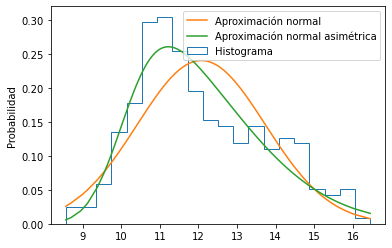

In [23]:
plt.hist(data1D, bins=20, density=True, histtype="step", label="Histograma")
ps = st.skewnorm.fit(data1D) # skewnorm estima la asimetría, la media y la varianza para nuestros datos
print("Estimadas: asimetría, media, desviación estándar" ,ps)
print("Empirícas: asimetría, media, desviación estándar" ,(asimetria,media,desviacion))
ys2 = st.skewnorm.pdf(data1D, *ps) # loc indica la media y scale la desviación
plt.plot(np.sort(data1D),ys[np.argsort(data1D)], label='Aproximación normal')
plt.plot(np.sort(data1D),ys2[np.argsort(data1D)], label='Aproximación normal asimétrica')
plt.ylabel("Probabilidad")
plt.legend();

### Curtosis

El siguiente momento, es conocido curtosis. Tiene una definición similar y, a menudo, se representa como $\kappa$ o $\gamma_2$:
$$ \kappa = \frac{E[(x-\mu)^4]}{E[(x-\mu)^2]^{4/2}} $$

Podemos calcular la curtosis con el siguiene snipet de código:

In [24]:
curtosis = st.kurtosis(data1D, fisher=False)
print("Cursotis", curtosis)

Cursotis 2.4632226302086364


El parámetro **fisher** es solo una normalización, esto debido a que existen múltiples definiciones de curtosis. Con `fisher = False`, una distribución normal tiene una curtosis de 3. Con` fisher = True`, scipy restaría 3 del resultado para que una distribución normal tenga una curtosis de 0. Muchas cosas se comparan con distribuciones normales, por lo que tener todos los momentos en 0 es decir normalizados puede resultar útil.

In [25]:
curtosis = st.kurtosis(data1D)
print("Cursotis no fisher", curtosis)
print("Cursotis - 3", st.kurtosis(data1D, fisher=False)-3)

Cursotis no fisher -0.5367773697913636
Cursotis - 3 -0.5367773697913636


## Datos atípicos

Es común que en problemas realeas los conjuntos de datos tengan datos faltates **NaN** o bien veces datos contienen valores atípicos, es decir que no son **similares** a los demás. A continuación mencionaremos algunas estraregia para lidiar con este tipo de datos. Revisemos mediante el siguiente ejemplo.

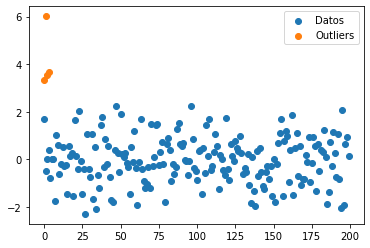

In [26]:
np.random.seed(7) # Semilla para reproducibilidad
datos=np.random.normal(size=200) # Datos 
outliers=np.random.normal(5,size=4)# Outliers
plt.scatter(range(len(datos)), datos, label="Datos")
plt.scatter(range(len(outliers)), outliers, label='Outliers')
plt.legend()

La forma más simple de remover datas atípico es asumiendo de estos siguen alguna distribución de probabilidad conocida, podríamos enumerar el proceso como sigue:

1. Modelar lo datos mediante una distribución de probabilidad.
2.  Encontrar y eliminar los datos por debajo de un umbral probabilidad.
3. Estimar nuevamente la probabilidad. 
4. Si se desea, repetir nuevamente desde el paso 1.

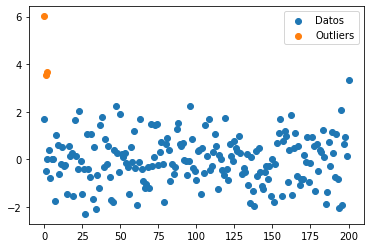

In [27]:
dout=np.concatenate((datos,outliers))
media, desv = np.mean(dout), np.std(dout) # Se asume una distribución normal

z_score = np.abs((dout - media) / desv) # calculamos que tan que tan alejado de la media 

umbral = 3# si el score es mayor que 3 
no_outliers = z_score < umbral  # No es outlier si no revasa el umbral

plt.scatter(range(len(dout[no_outliers])), dout[no_outliers], label="Datos")
plt.scatter(range(len(dout[~no_outliers])), dout[~no_outliers], label='Outliers')
plt.legend()

<div class="alert alert-success">
    <b>Ejercicio:</b> Modificar el valor de umbral y ver que ocurre.
 </div>

## Distribuciones

Existen muchas y bien estudiades distribuciones de probabilidad, pero en este curso solo mencionaremos algunas de las populares. Comenzaremos con un breve repaso de probabilidad.

- La probabilidad está definida en un rango de 0 a 1. Donde 0 implica un evento imposible,mientras que 1 la certeza de que ocurrirá.
- Una distribución relaciana un evento $x$ con la probabilidad $p(x)$ de que este ocurra. 
- La función de probabilidad de todos los posibles eventos suma 1.
- Cuando los eventos son discretos, $p(x)$ se conoce como función de masa.

Por ejemplo, los eventos probables de lanzar un dado son 6, es decir que salga una de su 6 caras. Se cumple que conforme el número de veces que lo lancemos se incremete, todos los números tenderar a ocurrir el mismo número de veces. Si el dado no está cargado cada cara tiene $1/6$ de probabilidad de salir en cada intento.

### Distribución Uniforme

Como en el caso del lanzamiento de un dado los eventos son igualmente probables, se dice que se tiene una distribución uniforme. La probabilidad de que un valor dado este e definida en un rango de valores entre $a$ y $b$ está dada por:

$$p(x|a,b)=\frac{1}{a-b}$$

en la expresión previa la probabilidad depende de los párametros $a$ y $b$.

La funcion np.random.randint generar números en utilizando una distribución uniforme, es decir una función de masa, mientras que rand genera números continuos. 

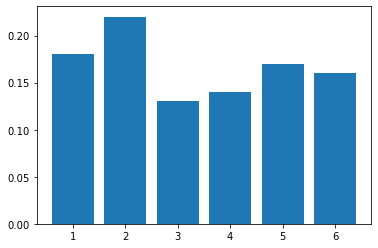

In [28]:
# Utilizaremos la librería stats nuevamente
a=1 #limete inferior
b=7 #limete superior el intervalo es abierto
N=100 # Conforme N tiende a infinito la frecuencia de cada barra tenderá a 1/N
np.random.seed(1)
uniforme_discreta=np.random.randint(low=a, high=7, size=N)
hist,edges=np.histogram(uniforme_discreta, bins=6)
plt.bar(range(1,len(hist)+1),hist/N); # divididmos entre el número total de eventos para convertir en probabilidad


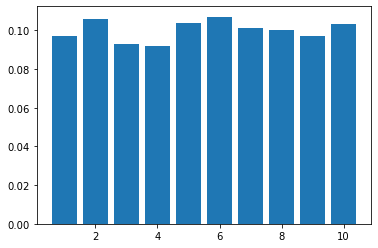

In [29]:
# En un rango discreto
a=-1 #limete inferior
b=2 #limete superior el intervalo es abierto
N=1000
np.random.seed(1)
uniforme_continua=np.random.uniform(low=a, high=b, size=N)
hist,edges=np.histogram(uniforme_continua, bins=10)
plt.bar(range(1,len(hist)+1),hist/N);# En amabos casos la suma de todos las probabilidades es 1

##  Distribución Binomial

Esta dada por la siguiente ecuación:

$$P(k|n,p)=\frac{n!}{k!(n-k)!}p^k(1-p)^{n-k}$$

Está parametrizada por $n$ y $p$ y proporcion la probabilidad de tener $k$ éxitos, dato que se realizan $n$ intententos cada uno con o probabilidas $p$. Por ejemplo cual es la probabilidad de obtener 10 veces el número 6, si se realizan 20 lanzamientos. Determina la probabilida de que un evento ocurra ($p$) vs que este no ocurra ($1-p$).

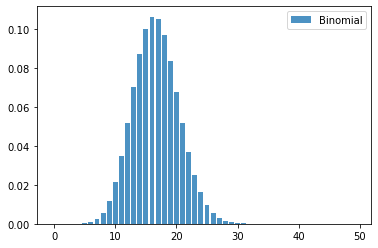

In [30]:
k=np.arange(50) # 50 posibles valores
n=100 #  100 eventos
p=1/6 # un sexto de probabilidad de éxito en cada evento
pmf_binom = st.binom.pmf(k,n,p)
plt.bar(k, pmf_binom, label="Binomial", alpha=0.8)
plt.legend()

Podemos obtener la probabilida de obtener la probabilidad de obtener 10 veces el número 1.

In [31]:
st.binom.pmf(10,50,1/6) # 11%

0.11558578469188747

##  Distribución normal

Esta distribución se define en función de media $\mu$ y la desviación estandar $\sigma$ mediante la siguiente equación:

$$p(x|\mu,\sigma)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

El termino  $\frac{1}{\sqrt{2\pi\sigma^2}}$ es una nomalización para que el área bajo la curva de la curva gaussiana sume 1. La media designa el pico de la curva, $\sigma$ indica la amplitud de la misma. Muchas otras distribuciones pueden convertirse en una distrubución normal dependiendo de los valores de sus parámetros.

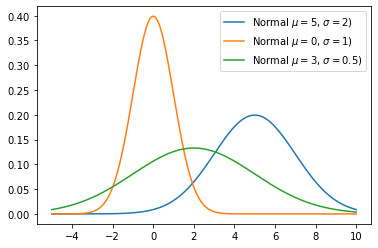

In [32]:
# Ejemplos
xs=np.linspace(-5,10,2000)
pdf_normal = st.norm.pdf(xs, loc=5, scale=2)
plt.plot(xs, pdf_normal, label="Normal $\mu=5$, $\sigma=2$)")
pdf_normal = st.norm.pdf(xs, loc=0, scale=1)
plt.plot(xs, pdf_normal, label="Normal $\mu=0$, $\sigma=1$)")
pdf_normal = st.norm.pdf(xs, loc=2, scale=3)
plt.plot(xs, pdf_normal, label="Normal $\mu=3$, $\sigma=0.5$)")
plt.legend();

El siguiente gráfico resume algunas de las más utilizadas y se deja como ejercicio al estudiante revisar sus los parámetros de cada una.

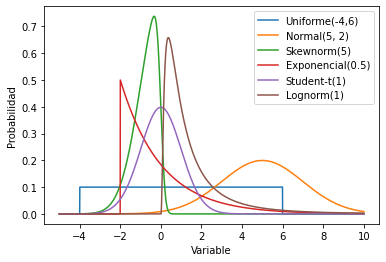

In [33]:
xs = np.linspace(-5, 10, 2000)
ks = np.arange(50)

pdf_uniform = st.uniform.pdf(xs, -4, 10)
plt.plot(xs, pdf_uniform, label="Uniforme(-4,6)")

pdf_normal = st.norm.pdf(xs, loc=5, scale=2)
plt.plot(xs, pdf_normal, label="Normal(5, 2)")


pdf_skewnorm = st.skewnorm.pdf(xs, -6)
plt.plot(xs, pdf_skewnorm, label="Skewnorm(5)")


pdf_exponential = st.expon.pdf(xs, loc=-2, scale=2)
plt.plot(xs, pdf_exponential, label="Exponencial(0.5)")

pdf_studentt = st.t.pdf(xs, 100)
plt.plot(xs, pdf_studentt, label="Student-t(1)")

pdf_lognorm = st.lognorm.pdf(xs, 1)
plt.plot(xs, pdf_lognorm, label="Lognorm(1)")

plt.legend()
plt.ylabel("Probabilidad")
plt.xlabel("Variable");

## Actividad

<div class="alert alert-success">
    Tomando los datos de casos confirmados y/o muertes confirmadas por COVID-19:
       <ul>
    <li>Elija 3 paises y determine si es posible ajustar alguna de las variables muertes/casos confirmados a alguna distribución de las listadas.
              <ul>
           <li>Tabule los datos de media, mediana, moda, varianza, asimetría y curtosis. Indique que explica cada una de ellas</li>
           <li>Identifique outliers (visualmente determine el umbral adecuado)</li>
           <li>En caso de ser viable el ajuste, grafique la distribución</li>
           </ul>
           </li>
          <li>Determine como podría realizarse una comparación del impacto de la pandemia en cada uno de los países
           <ul>
           <li>Explique su razonamiento</li>
               <li>Genere algunas visualizaciones de comparaciones</li>
           </ul>
           </li>
           </ul>
</div>

### Breve ejemplo de como acceder a los datos

In [34]:
import requests
import pandas as pd
import io

In [35]:
# Url del archivo con las estadisticas globales de casos confirmados de covid
confirmados="time_series_covid19_confirmed_global.csv"
muertes="time_series_covid19_deaths_global.csv"
base="https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/"
url_confirmados=f"{base}{confirmados}" 
url_muertes=f"{base}{muertes}" 

In [36]:
r=requests.get(url_confirmados)# obtenemos los datos
df=pd.read_csv(io.StringIO(r.content.decode('utf-8')))

In [37]:
df.head() # Contiens las estadisticas del total de casos confirmados para para a partir del primero 22 de Enero del 2020 

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21,5/30/21,5/31/21,6/1/21,6/2/21,6/3/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,66903,67743,68366,69130,70111,70761,71838,72977,74026,75119
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132229,132244,132264,132285,132297,132309,132315,132337,132351,132360
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,127361,127646,127926,128198,128456,128725,128913,129218,129640,129976
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13664,13671,13682,13693,13693,13693,13727,13729,13744,13752
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,32933,33338,33607,33944,34180,34366,34551,34752,34960,35140


In [38]:
casos_mexico=df[df['Country/Region']=='Mexico'].values[0][4:] # Tomamos los datos para México
casos_japon=df[df['Country/Region']=='Japan'].values[0][4:] # Tomamos los datos para Japón 
nd=len(casos_mexico)

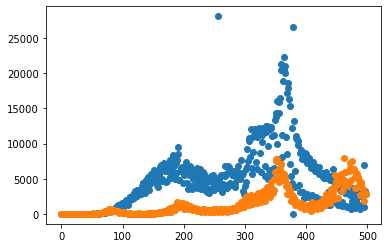

In [39]:
# Gráfico simple de comparación de casos confirmados entre México y Japón
plt.scatter(range(nd-1),np.diff(casos_mexico), label="México") # Incremento diario
plt.scatter(range(nd-1),np.diff(casos_japon), label="Japón")  # Incremento diario

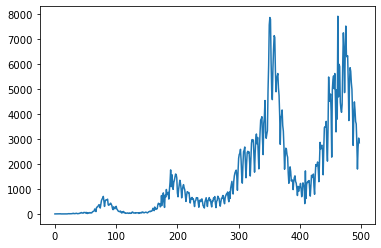

In [40]:
casos_diarios=np.diff(casos_japon)
plt.plot(casos_diarios, label="Japón")

In [41]:
xs=np.linspace(-10,12,2000)
pdf_normal = st.norm.pdf(xs, loc=-1, scale=1)
plt.plot(xs, pdf_normal/mm, label="$C_2,C_3$",c='red')
pdf_normal = st.norm.pdf(xs, loc=2, scale=2)
plt.plot(xs, pdf_normal/mm, label="$C_1,C_3$",c='k')
pdf_normal = st.norm.pdf(xs, loc=3, scale=3.5)
plt.plot(xs, pdf_normal/mm, label="$C_2,C_3$",c='k')
plt.legend();
plt.xlim(-10,12)
plt.yticks([]);
plt.xticks([]);
plt.title('Varianza')

NameError: name 'mm' is not defined

In [ ]:
pdf_normal

In [ ]:
xs

In [ ]:
pdf_normal/mm